In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import os
from dotenv import load_dotenv

In [4]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

multi_lexsum = load_dataset("allenai/multi_lexsum", name="v20230518", trust_remote_code=True, token=hf_token)

## 1. Data Exploration

Explore the Multi-LexSum dataset structure, feature statistics, and sample records.

In [5]:
# Dataset structure overview
print("Available splits:", list(multi_lexsum.keys()))
print("\nFeatures:")
print(multi_lexsum['train'].features)
print(f"\nSplit sizes:")
for split in multi_lexsum:
    print(f"  {split}: {len(multi_lexsum[split]):,} examples")

# Inspect a single record
sample = multi_lexsum['train'][0]
print("\n--- Sample record preview ---")
for k, v in sample.items():
    if isinstance(v, list):
        preview = f"[list of {len(v)} items; first 100 chars: {str(v[0])[:100]}...]"
    else:
        preview = str(v)[:200] if v is not None else "None"
    print(f"  {k}: {preview}")

Available splits: ['train', 'validation', 'test']

Features:
{'id': Value(dtype='string', id=None), 'sources': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'sources_metadata': Sequence(feature={'doc_id': Value(dtype='string', id=None), 'doc_type': Value(dtype='string', id=None), 'doc_title': Value(dtype='string', id=None), 'parser': Value(dtype='string', id=None), 'is_ocr': Value(dtype='bool', id=None), 'url': Value(dtype='string', id=None)}, length=-1, id=None), 'summary/long': Value(dtype='string', id=None), 'summary/short': Value(dtype='string', id=None), 'summary/tiny': Value(dtype='string', id=None), 'case_metadata': {'case_name': Value(dtype='string', id=None), 'case_type': Value(dtype='string', id=None), 'filing_date': Value(dtype='string', id=None), 'filing_year': Value(dtype='string', id=None), 'case_ongoing': Value(dtype='string', id=None), 'case_ongoing_record_time': Value(dtype='string', id=None), 'closing_year': Value(dtype='string', id=None), 'ord

In [6]:
import collections

KEY_SUMMARY_COLS = ['summary/long', 'summary/short', 'summary/tiny']
# Labels live inside the `case_metadata` dict, not at the top level
LABEL_COLS = ['class_action_sought', 'case_type']

first_ex = multi_lexsum['train'][0]
all_cols = list(first_ex.keys())
print("All columns:", all_cols)
print("case_metadata keys:", list(first_ex['case_metadata'].keys()))

# Null rates for summary columns
print("\nNull rates across splits:")
for split_name in multi_lexsum:
    split = multi_lexsum[split_name]
    total = len(split)
    for col in KEY_SUMMARY_COLS:
        null_count = sum(1 for ex in split if ex[col] is None or ex[col] == '')
        print(f"  {split_name}/{col}: {null_count}/{total} null ({100*null_count/total:.1f}%)")

# Label distributions (train only) — pulled from case_metadata
print("\nLabel distributions (train split):")
for col in LABEL_COLS:
    vals = [ex['case_metadata'].get(col) for ex in multi_lexsum['train']]
    vals = [v for v in vals if v is not None and v != '']
    counts = collections.Counter(vals)
    print(f"\n  {col}:")
    for label, cnt in counts.most_common(10):
        print(f"    {label!r}: {cnt}")

All columns: ['id', 'sources', 'sources_metadata', 'summary/long', 'summary/short', 'summary/tiny', 'case_metadata']
case_metadata keys: ['case_name', 'case_type', 'filing_date', 'filing_year', 'case_ongoing', 'case_ongoing_record_time', 'closing_year', 'order_start_year', 'order_end_year', 'defendant_payment', 'class_action_sought', 'class_action_granted', 'attorney_orgs', 'prevailing_party', 'plaintiff_types', 'plaintiff_description', 'constitutional_clauses', 'causes_of_action', 'summary_authors', 'case_url']

Null rates across splits:
  train/summary/long: 0/3177 null (0.0%)
  train/summary/short: 967/3177 null (30.4%)
  train/summary/tiny: 2047/3177 null (64.4%)
  validation/summary/long: 0/454 null (0.0%)
  validation/summary/short: 142/454 null (31.3%)
  validation/summary/tiny: 293/454 null (64.5%)
  test/summary/long: 0/908 null (0.0%)
  test/summary/short: 292/908 null (32.2%)
  test/summary/tiny: 596/908 null (65.6%)

Label distributions (train split):

  class_action_sought

## 2. Build DataFrame

Combine all three splits into a single pandas DataFrame with: full concatenated case text, three summary levels, `case_action_sought`, and `case_type`.

In [7]:
def build_dataframe(dataset_dict):
    rows = []
    for split_name, split in dataset_dict.items():
        for ex in split:
            sources = ex.get('sources') or []
            full_text = "\n\n".join(sources) if sources else ""
            meta = ex.get('case_metadata') or {}
            rows.append({
                'id': ex.get('id', ''),
                'split': split_name,
                'full_text': full_text,
                'summary_long':  ex.get('summary/long'),
                'summary_short': ex.get('summary/short'),
                'summary_tiny':  ex.get('summary/tiny'),
                'class_action_sought': meta.get('class_action_sought'),
                'case_type':           meta.get('case_type'),
            })
    return pd.DataFrame(rows)

df = build_dataframe(multi_lexsum)
print(f"Total rows: {len(df):,}")
print(f"\nNull counts per column:\n{df.isnull().sum()}")
print(f"\nSplit breakdown:\n{df['split'].value_counts()}")
print(f"\nclass_action_sought distribution:\n{df['class_action_sought'].value_counts(dropna=False)}")
print(f"\ncase_type top 5:\n{df['case_type'].value_counts(dropna=False).head()}")
df.head(2)

Total rows: 4,539

Null counts per column:
id                        0
split                     0
full_text                 0
summary_long              0
summary_short          1401
summary_tiny           2936
class_action_sought       0
case_type                 0
dtype: int64

Split breakdown:
split
train         3177
test           908
validation     454
Name: count, dtype: int64

class_action_sought distribution:
class_action_sought
No         3026
Yes        1510
Unknown       3
Name: count, dtype: int64

case_type top 5:
case_type
Equal Employment                         1579
Immigration and/or the Border             523
Prison Conditions                         424
Jail Conditions                           303
Public Benefits / Government Services     288
Name: count, dtype: int64


,id,split,full_text,summary_long,summary_short,summary_tiny,class_action_sought,case_type
0,EE-AL-0045,train,Case 1:05-cv-00530-D Document 1-1 Filed 09/19/...,"On September 15, 2005, the Equal Employment Op...",Equal Employment Opportunity Commission brough...,NaN,No,Equal Employment
1,PB-NJ-0003,train,Case 3:05-cv-01784-SRC-JJH Document 2 Filed 05...,NOTE: This is one of three identically named ...,The case was brought by a non-profit organizat...,NaN,No,Public Benefits / Government Services


## 3. Text Cleaning

Normalize the `full_text` column: strip HTML tags, remove non-ASCII characters, lowercase, and collapse whitespace.

In [8]:
import re

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)            # strip HTML/XML tags
    text = text.encode('ascii', 'ignore').decode()   # drop non-ASCII characters
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\.\,\!\?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

print(f"Max document length:  {df['clean_text'].str.len().max():,} chars")
print(f"Mean document length: {df['clean_text'].str.len().mean():,.0f} chars")
print(f"\nCleaned sample (first 500 chars):\n{df['clean_text'].iloc[0][:500]}")

Max document length:  19,857,616 chars
Mean document length: 330,713 chars

Cleaned sample (first 500 chars):
case 1 05 cv 00530 d document 1 1 filed 09 19 2005 page 1 of 6 in the united states district fild cour t p19 .05 nl el .s for the southern district of alabama southern division equal employment opportunity commission, plaintiff, civil action no. oss 0 53a v. complaint house of philadelphia center, inc . jury trial demand defendant . nature of the action this is an action under title vii of the civil rights act of 1964 and title i of the civil rights act of 1991 to correct unlawful employment pra


## 4. Summarization

Use a pre-trained DistilBART model to generate long, short, and tiny summaries, then compare to the expert-authored ground truth in the dataset.

In [11]:
# transformers v5 removed the pipeline `summarization` task, so we drive the
# seq2seq model directly via AutoTokenizer + AutoModelForSeq2SeqLM.
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "sshleifer/distilbart-cnn-12-6"  # fast; swap for facebook/bart-large-cnn for higher quality
_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
_model.eval()

# Three length tiers — (max_new_tokens, min_new_tokens)
LENGTH_PRESETS = {
    'long':  (250, 100),
    'short': (100, 40),
    'tiny':  (40, 15),
}

def _summarize(text: str, max_len: int, min_len: int) -> str:
    inputs = _tokenizer(text, return_tensors='pt', truncation=True, max_length=1024)
    with torch.no_grad():
        out = _model.generate(
            **inputs,
            max_new_tokens=max_len,
            min_new_tokens=min_len,
            num_beams=4,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    return _tokenizer.decode(out[0], skip_special_tokens=True).strip()

def generate_summaries(text: str) -> dict:
    """Generate long/short/tiny summaries. The model truncates inputs to 1024 tokens internally."""
    trunc = text[:6000] if text else ""
    if len(trunc.split()) < 30:
        return {k: trunc for k in LENGTH_PRESETS}
    return {tier: _summarize(trunc, mx, mn) for tier, (mx, mn) in LENGTH_PRESETS.items()}

# Demo on 3 training cases that have ground-truth tiny summaries
demo = df[(df['split'] == 'train') & df['summary_tiny'].notna()].head(3)

for _, row in demo.iterrows():
    generated = generate_summaries(row['clean_text'])
    print(f"\n{'='*70}")
    print(f"Case ID: {row['id']}")
    print(f"\n[Generated long]\n{generated['long']}")
    print(f"\n[Generated short]\n{generated['short']}")
    print(f"\n[Generated tiny]\n{generated['tiny']}")
    print(f"\n[Ground truth tiny]\n{row['summary_tiny']}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...


Case ID: PB-WV-0002

[Generated long]
Six lesbian and gay west virginians who comprise three loving and committed same sex couples, adult plaintiffs or plaintiff couples, and a child of one of the couples child plaintiff collectively, all plaintiffs . All plaintiffs seek declaratory and injunctive relief for the violation of their guarantees of liberty and equal protection under the fourteenth amendment to the united states constitution as a result of west virginia statutes that expressly deny same sex . couples the right to marry the person of their choice based solely on their sexual orientation and sex . The state also interferes with the constitutionally protected liberty and privacy interests in familial association and integrity of a.s.m. and other similarly 2

[Generated short]
Six lesbian and gay west virginians who comprise three loving and committed same sex couples, adult plaintiffs or plaintiff couples, and a child of one of the couples child plaintiff collectively, all pl

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


Case ID: PN-MI-0008

[Generated long]
The grand rapids police department has a policy, practice or custom of arresting individuals for trespass, without warning, at businesses open to the public . The plaintiffs seek a declaration that their rights were violated, an injunction against future arrests for criminal trespass based solely on the letters of intent, and damages to compensate them for their unlawful arrests . This is a civil action seeking redress for the deprivation of rights secured by the united states constitution, and the venue is proper in the western district of michigan pursuant to 28 u.s.c. 1391 b .

[Generated short]
The grand rapids police department has a policy, practice or custom of arresting individuals for trespass, without warning, at businesses open to the public . The plaintiffs seek a declaration that their rights were violated, an injunction against future arrests for criminal trespass based solely on the letters of intent, and damages to compensate them 

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


Case ID: PC-MI-0036

[Generated long]
Inmates are deaf or hard of hearing inmates in the custody of the michigan department of corrections the department or mdoc . While in custody, plaintiffs have been denied the assistance and accommodation that they require to effectively communicate and to participate in mdoc programs, services, and activities, in violation of the americans with disabilities act ada , 42 u.s.c. 12131 et seq., the rehabilitation act, 29 u.S. 794 et seq. and the religious land use and institutionalized persons act rluipa . and the first and fourteenth amendments of the constitution .

[Generated short]
Inmates are deaf or hard of hearing inmates in the custody of the michigan department of corrections the department or mdoc . While in mdoc custody, plaintiffs have been denied the assistance and accommodation that they require to effectively communicate . Defendants have been excluded from a variety of programs and activities offered by the department, have been puni

## 5. Classification Model — `class_action_sought`

Predict whether a class action was sought (binary). Three models: Naive Bayes, Logistic Regression, and a TensorFlow dense network, all trained on TF-IDF features.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Use training split; drop rows with missing labels, "Unknown" (only 2 cases), or empty text
mask = (
    (df['split'] == 'train')
    & df['class_action_sought'].notna()
    & df['class_action_sought'].isin(['Yes', 'No'])
    & (df['clean_text'].str.len() > 50)
)
train_df = df[mask].copy()

X = train_df['clean_text']
y = train_df['class_action_sought']
print(f"Training examples: {len(X)}")
print(f"Label distribution:\n{y.value_counts()}\n")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("--- Naive Bayes ---")
print(classification_report(y_val, nb.predict(X_val_tfidf)))

lr = LogisticRegression(max_iter=500, C=1.0)
lr.fit(X_train_tfidf, y_train)
print("--- Logistic Regression ---")
print(classification_report(y_val, lr.predict(X_val_tfidf)))

Training examples: 3175
Label distribution:
class_action_sought
No     2109
Yes    1066
Name: count, dtype: int64

--- Naive Bayes ---
              precision    recall  f1-score   support

          No       0.92      0.69      0.79       422
         Yes       0.59      0.88      0.70       213

    accuracy                           0.75       635
   macro avg       0.75      0.78      0.75       635
weighted avg       0.81      0.75      0.76       635

--- Logistic Regression ---
              precision    recall  f1-score   support

          No       0.92      0.99      0.95       422
         Yes       0.97      0.84      0.90       213

    accuracy                           0.94       635
   macro avg       0.95      0.91      0.93       635
weighted avg       0.94      0.94      0.94       635



In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

le_action = LabelEncoder()
y_train_enc = le_action.fit_transform(y_train)
y_val_enc = le_action.transform(y_val)

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_val_dense = X_val_tfidf.toarray().astype('float32')

model_action = keras.Sequential([
    keras.layers.Input(shape=(X_train_dense.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(len(le_action.classes_), activation='softmax'),
])
model_action.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_action.summary()

history_action = model_action.fit(
    X_train_dense, y_train_enc,
    validation_data=(X_val_dense, y_val_enc),
    epochs=10, batch_size=32, verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history_action.history['accuracy'], label='Train')
plt.plot(history_action.history['val_accuracy'], label='Val')
plt.title('TF Model — class_action_sought — Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

preds_action = le_action.inverse_transform(model_action.predict(X_val_dense).argmax(axis=1))
print("--- TensorFlow Dense NN (class_action_sought) ---")
print(classification_report(y_val, preds_action))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,514 (2.47 MB)

 Trainable params: 648,514 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


## 6. Classification Model — `case_type`

Predict case type (multi-class). Rare types are grouped into **"Other"** to keep at least `TOP_N + 1` classes with sufficient training examples.

In [ ]:
TOP_N = 5
type_counts = train_df['case_type'].value_counts()
top_types = set(type_counts.head(TOP_N).index)

def map_case_type(t):
    return t if pd.notna(t) and t in top_types else 'Other'

Xt = train_df['clean_text']
yt = train_df['case_type'].apply(map_case_type)

print(f"Label distribution after grouping:\n{yt.value_counts()}\n")

Xt_train, Xt_val, yt_train, yt_val = train_test_split(Xt, yt, test_size=0.2, random_state=42, stratify=yt)

Xt_train_tfidf = vectorizer.transform(Xt_train)
Xt_val_tfidf = vectorizer.transform(Xt_val)

nb_type = MultinomialNB()
nb_type.fit(Xt_train_tfidf, yt_train)
print("--- Naive Bayes (case_type) ---")
print(classification_report(yt_val, nb_type.predict(Xt_val_tfidf)))

lr_type = LogisticRegression(max_iter=500, C=1.0)
lr_type.fit(Xt_train_tfidf, yt_train)
print("--- Logistic Regression (case_type) ---")
print(classification_report(yt_val, lr_type.predict(Xt_val_tfidf)))

Label distribution after grouping:
case_type
Equal Employment                         1098
Other                                     971
Immigration and/or the Border             367
Prison Conditions                         312
Jail Conditions                           223
Public Benefits / Government Services     204
Name: count, dtype: int64

--- Naive Bayes (case_type) ---
                                       precision    recall  f1-score   support

                     Equal Employment       0.94      0.90      0.92       220
       Immigration and/or the Border        0.88      0.81      0.84        73
                      Jail Conditions       0.93      0.56      0.69        45
                                Other       0.67      0.87      0.76       194
                    Prison Conditions       0.70      0.74      0.72        62
Public Benefits / Government Services       0.71      0.24      0.36        41

                             accuracy                           0

Epoch 1/10


c:\Users\paulk\Documents\MLDS414\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5996 - loss: 1.0617 - val_accuracy: 0.7669 - val_loss: 0.6970
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8181 - loss: 0.5324 - val_accuracy: 0.8756 - val_loss: 0.3877
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8969 - loss: 0.3098 - val_accuracy: 0.8992 - val_loss: 0.3094
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9248 - loss: 0.2213 - val_accuracy: 0.8961 - val_loss: 0.2816
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9484 - loss: 0.1586 - val_accuracy: 0.9165 - val_loss: 0.2576
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.1201 - val_accuracy: 0.9039 - val_loss: 0.2858
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9705 - loss: 0.0869 - val_accuracy: 0.9087 - val_loss: 0.3067
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9823 - loss: 0.0701 - val_accuracy: 0.9055 - val_loss: 0.2963
Epo

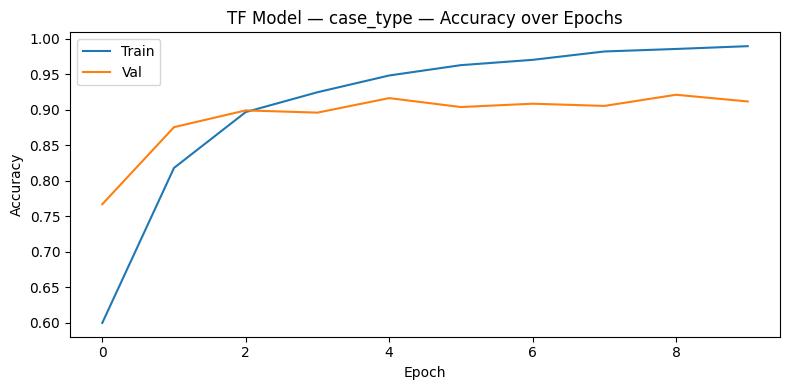

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
--- TensorFlow Dense NN (case_type) ---
                                       precision    recall  f1-score   support

                     Equal Employment       0.97      1.00      0.98       220
       Immigration and/or the Border        0.92      0.90      0.91        73
                      Jail Conditions       0.83      0.87      0.85        45
                                Other       0.94      0.85      0.89       194
                    Prison Conditions       0.89      0.87      0.88        62
Public Benefits / Government Services       0.68      0.88      0.77        41

                             accuracy                           0.91       635
                            macro avg       0.87      0.89      0.88       635
                         weighted avg       0.92      0.91      0.91       635



In [ ]:
le_type = LabelEncoder()
yt_train_enc = le_type.fit_transform(yt_train)
yt_val_enc = le_type.transform(yt_val)

Xt_train_dense = Xt_train_tfidf.toarray().astype('float32')
Xt_val_dense = Xt_val_tfidf.toarray().astype('float32')

model_type = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(Xt_train_dense.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(len(le_type.classes_), activation='softmax'),
])
model_type.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_type = model_type.fit(
    Xt_train_dense, yt_train_enc,
    validation_data=(Xt_val_dense, yt_val_enc),
    epochs=10, batch_size=32, verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history_type.history['accuracy'], label='Train')
plt.plot(history_type.history['val_accuracy'], label='Val')
plt.title('TF Model — case_type — Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

preds_type = le_type.inverse_transform(model_type.predict(Xt_val_dense).argmax(axis=1))
print("--- TensorFlow Dense NN (case_type) ---")
print(classification_report(yt_val, preds_type))

## 7. Interactive Tool

Input any legal case text to receive long, short, and tiny summaries plus predictions for `case_action_sought` and `case_type`. Run the cell below and use the widget.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

text_input = widgets.Textarea(
    placeholder='Paste a legal case description here...',
    layout=widgets.Layout(width='100%', height='200px')
)
run_btn = widgets.Button(description='Analyze Case', button_style='primary', icon='search')
output_area = widgets.Output()

def on_analyze(b):
    with output_area:
        clear_output(wait=True)
        raw = text_input.value.strip()
        if not raw:
            print("Please enter a legal case description.")
            return

        cleaned = clean_text(raw)
        vec = vectorizer.transform([cleaned])

        print("Generating summaries (this may take ~30s)...")
        sums = generate_summaries(cleaned)

        pred_action = lr.predict(vec)[0]
        pred_type = lr_type.predict(vec)[0]

        display(Markdown(f"""
---
### Summaries

**Long:**  
{sums['long']}

**Short:**  
{sums['short']}

**Tiny:**  
{sums['tiny']}

---
### Predictions

| Field | Prediction |
|-------|-----------|
| Class action sought | `{pred_action}` |
| Case type | `{pred_type}` |
"""))

run_btn.on_click(on_analyze)
display(widgets.VBox([text_input, run_btn, output_area]))

## 8. Additional Techniques — Word Frequency & Word Clouds

Visualize the most discriminative TF-IDF terms per class for both classifiers.

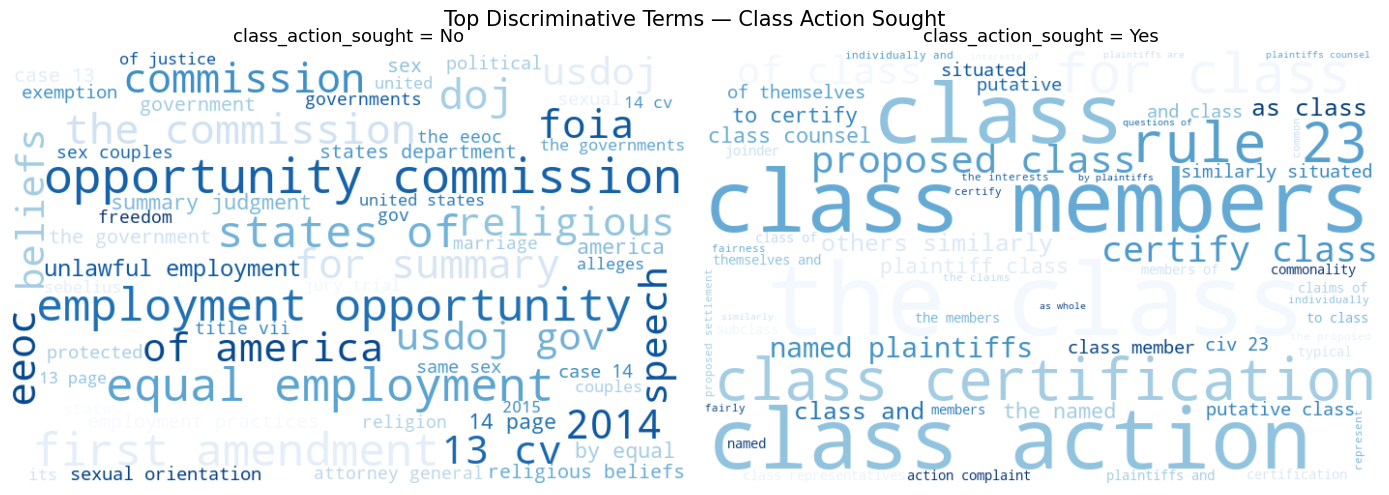

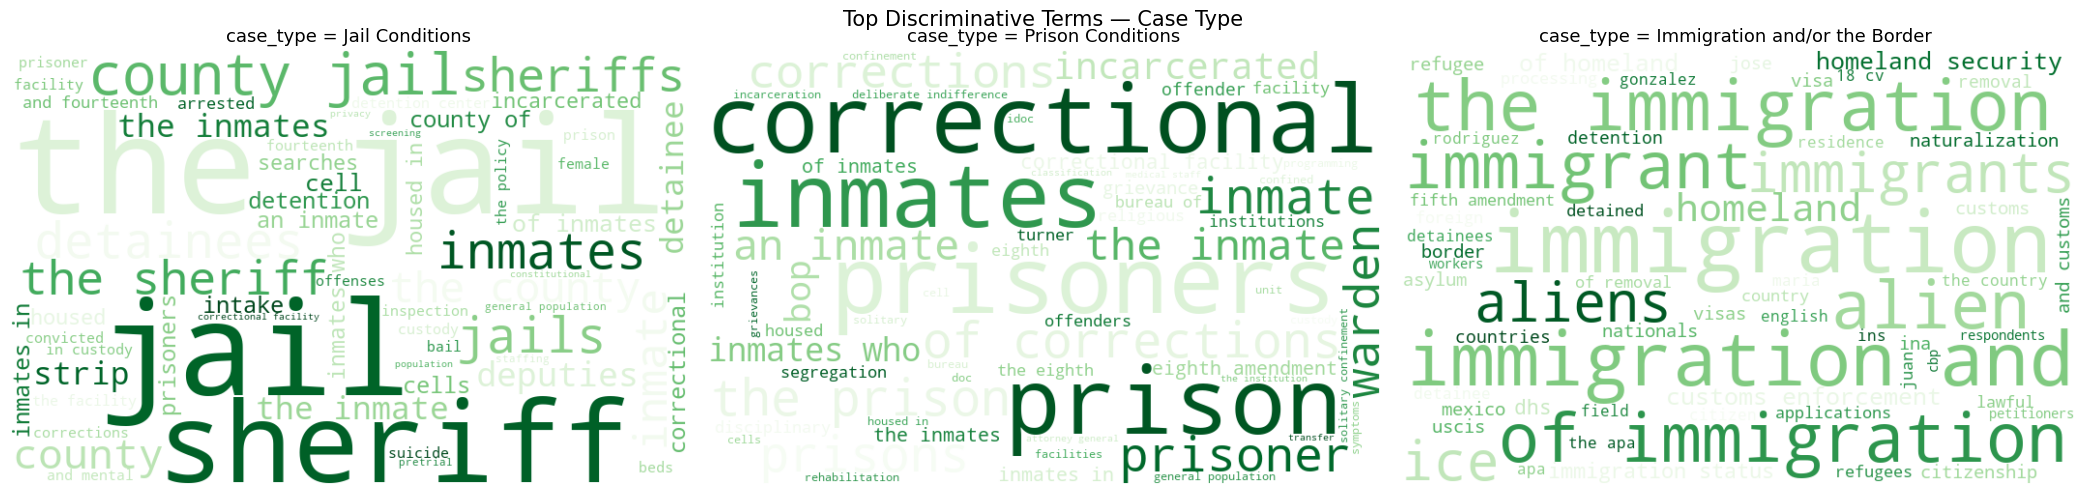

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

feature_names = vectorizer.get_feature_names_out()

# Word clouds for class_action_sought (LR log-odds coefficients)
classes = lr.classes_
coef_matrix = np.vstack([-lr.coef_[0], lr.coef_[0]]) if len(classes) == 2 else lr.coef_

fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 5))
axes = [axes] if len(classes) == 1 else axes
for ax, cls, coef in zip(axes, classes, coef_matrix):
    top_idx = coef.argsort()[-60:]
    top_words = {feature_names[i]: float(coef[i]) for i in top_idx if coef[i] > 0}
    wc = WordCloud(width=700, height=450, background_color='white', colormap='Blues')
    wc.generate_from_frequencies(top_words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'class_action_sought = {cls}', fontsize=13)
    ax.axis('off')
plt.suptitle("Top Discriminative Terms — Class Action Sought", fontsize=15)
plt.tight_layout()
plt.show()

# Word clouds for the top 3 case types
fig2, axes2 = plt.subplots(1, min(3, TOP_N), figsize=(7 * min(3, TOP_N), 5))
for ax, cls in zip(axes2, list(top_types)[:3]):
    if cls not in lr_type.classes_:
        continue
    idx = list(lr_type.classes_).index(cls)
    coef = lr_type.coef_[idx]
    top_idx = coef.argsort()[-60:]
    top_words = {feature_names[i]: float(coef[i]) for i in top_idx if coef[i] > 0}
    wc = WordCloud(width=700, height=450, background_color='white', colormap='Greens')
    wc.generate_from_frequencies(top_words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'case_type = {cls}', fontsize=13)
    ax.axis('off')
plt.suptitle("Top Discriminative Terms — Case Type", fontsize=15)
plt.tight_layout()
plt.show()